<a href="https://colab.research.google.com/github/shruti956/breast-cancer-classification/blob/main/breast_cancer_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Classification Using Logistic Regression

This project implements logistic regression from scratch using NumPy to classify breast tumors as malignant or benign.

The project covers data exploration, feature scaling, model training using gradient descent and regularization, and evaluation using classification metrics and visualizations.

The core logistic regression concepts and functions used in this project were learned through Andrew Ng's *Supervised Machine Learning: Regression and Classification* course on Coursera and adapted to this dataset.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
df = cancer.frame

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Dataset Overview

The Wisconsin Diagnostic Breast Cancer dataset contains numerical features computed from digitized images of breast mass samples. The target variable represents whether a tumor is malignant or benign.

In [22]:
print("Dataset shape:", df.shape)

print("\nTarget names:", cancer.target_names)

print("\nClass distribution:")
print(df["target"].value_counts())

print("\nMissing values:", df.isnull().sum().sum())

Dataset shape: (569, 31)

Target names: ['malignant' 'benign']

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

Missing values: 0


In [23]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## Preparing Features and Target

The input features are separated from the target variable. The target uses:

- `0` — Malignant
- `1` — Benign

In [24]:
X = df.drop(columns=["target"]).to_numpy()
y = df["target"].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


## Train-Test Split

The dataset is divided into training and testing sets. The model is trained on 80% of the data and evaluated on the remaining 20% of unseen data.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training examples:", X_train.shape[0])
print("Testing examples:", X_test.shape[0])

Training examples: 455
Testing examples: 114


## Feature Scaling

Z-score normalization is applied to the input features so that features with different numerical scales can be handled effectively by gradient descent.

The mean and standard deviation are calculated only from the training data and then reused to normalize the test data.

In [26]:
def zscore_normalize_features(X):
    """
    Applies z-score normalization to each feature.
    """
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [27]:
X_train_norm, mu, sigma = zscore_normalize_features(X_train)

X_test_norm = (X_test - mu) / sigma

print("Normalized training shape:", X_train_norm.shape)
print("Normalized testing shape:", X_test_norm.shape)

Normalized training shape: (455, 30)
Normalized testing shape: (114, 30)


## Logistic Regression from Scratch

The following functions implement the core components of logistic regression, beginning with the sigmoid activation function and the logistic loss function.

In [28]:
def sigmoid(z):
    """
    Computes the sigmoid of z.
    """
    g = 1 / (1 + np.exp(-z))
    return g

In [29]:
def compute_cost(X, y, w, b, *argv):
    """
    Computes the logistic regression cost over all training examples.
    """
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)

        # Prevent log(0)
        f_wb_i = np.clip(f_wb_i, 1e-15, 1 - 1e-15)

        cost += -(
            y[i] * np.log(f_wb_i)
            + (1 - y[i]) * np.log(1 - f_wb_i)
        )

    return cost / m

In [30]:
def compute_gradient(X, y, w, b, *argv):
    """
    Computes the gradients of the logistic regression cost
    with respect to w and b.
    """
    m, n = X.shape

    dj_dw = np.zeros(w.shape)
    dj_db = 0.0

    for i in range(m):
        z_wb = np.dot(X[i], w) + b
        f_wb = sigmoid(z_wb)

        error = f_wb - y[i]

        dj_db += error

        for j in range(n):
            dj_dw[j] += error * X[i, j]

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_db, dj_dw

In [31]:
def compute_cost_reg(X, y, w, b, lambda_=1):
    """
    Computes logistic regression cost with L2 regularization.
    """
    m = X.shape[0]

    cost_without_reg = compute_cost(X, y, w, b)

    reg_cost = (lambda_ / (2 * m)) * np.sum(w ** 2)

    total_cost = cost_without_reg + reg_cost

    return total_cost


def compute_gradient_reg(X, y, w, b, lambda_=1):
    """
    Computes logistic regression gradients with L2 regularization.
    """
    m = X.shape[0]

    dj_db, dj_dw = compute_gradient(X, y, w, b)

    dj_dw = dj_dw + (lambda_ / m) * w

    return dj_db, dj_dw

## Model Training

The model parameters are optimized using batch gradient descent with L2 regularization.

In [32]:
def gradient_descent(X, y, w_in, b_in,
                     cost_function, gradient_function,
                     alpha, num_iters, lambda_):

    J_history = []

    w = w_in.copy()
    b = b_in

    for i in range(num_iters):

        # Compute gradients
        dj_db, dj_dw = gradient_function(
            X, y, w, b, lambda_
        )

        # Update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Store cost
        cost = cost_function(X, y, w, b, lambda_)
        J_history.append(cost)

        # Print progress approximately 10 times
        if i % math.ceil(num_iters / 10) == 0:
            print(
                f"Iteration {i:4d}: "
                f"Cost {J_history[-1]:.6f}"
            )

    return w, b, J_history

In [33]:
# Initialize parameters
initial_w = np.zeros(X_train_norm.shape[1])
initial_b = 0.0

# Training settings
alpha = 0.01
num_iters = 1000
lambda_ = 1.0

# Train the model
w_final, b_final, J_history = gradient_descent(
    X_train_norm,
    y_train,
    initial_w,
    initial_b,
    compute_cost_reg,
    compute_gradient_reg,
    alpha,
    num_iters,
    lambda_
)

print("\nFinal bias:", b_final)

Iteration    0: Cost 0.673011
Iteration  100: Cost 0.244216
Iteration  200: Cost 0.182913
Iteration  300: Cost 0.155209
Iteration  400: Cost 0.138900
Iteration  500: Cost 0.127983
Iteration  600: Cost 0.120079
Iteration  700: Cost 0.114047
Iteration  800: Cost 0.109265
Iteration  900: Cost 0.105365

Final bias: 0.3057379996126666


## Training Progress

The logistic regression cost is plotted against the number of gradient descent iterations to visualize the learning process.

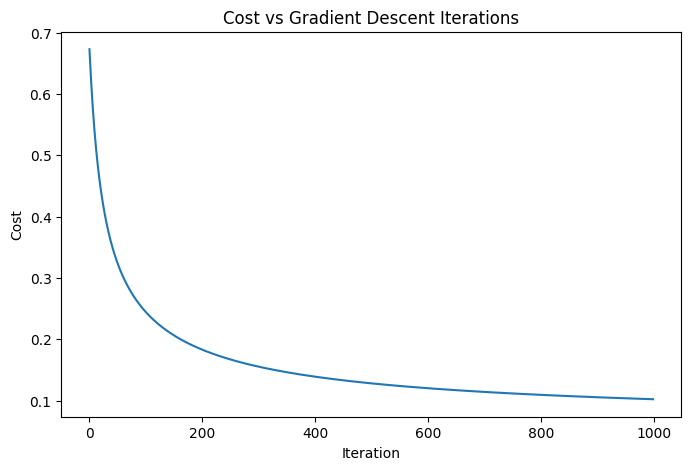

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(J_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Gradient Descent Iterations")

plt.show()

## Model Evaluation

The trained model is evaluated on unseen test data using accuracy, precision, recall, and F1 score.

In [35]:
def predict(X, w, b):
    """
    Predicts class labels using a probability threshold of 0.5.
    """
    m = X.shape[0]
    predictions = np.zeros(m)

    for i in range(m):
        z = np.dot(X[i], w) + b
        probability = sigmoid(z)

        if probability > 0.5:
            predictions[i] = 1
        else:
            predictions[i] = 0

    return predictions

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = predict(X_test_norm, w_final, b_final)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9736842105263158
Precision: 0.9859154929577465
Recall: 0.9722222222222222
F1 Score: 0.9790209790209791


## Confusion Matrix

The confusion matrix shows how many malignant and benign tumors were classified correctly or incorrectly.

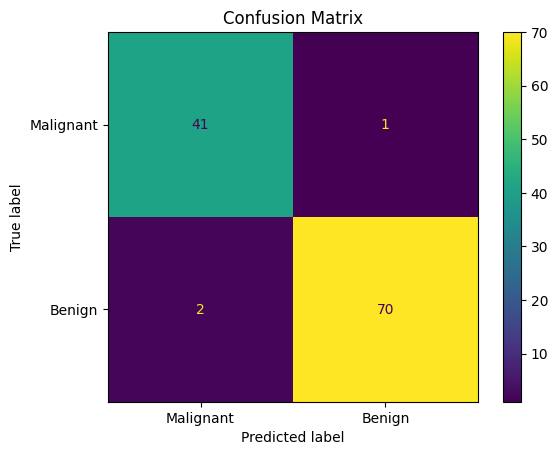

[[41  1]
 [ 2 70]]


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

print(cm)

In [38]:
malignant_recall = recall_score(y_test, y_pred, pos_label=0)

print("Malignant Recall:", malignant_recall)

Malignant Recall: 0.9761904761904762


## ROC Curve and AUC

The ROC curve evaluates the classifier across different probability thresholds. The Area Under the Curve (AUC) summarizes the model's ability to distinguish between the two classes.

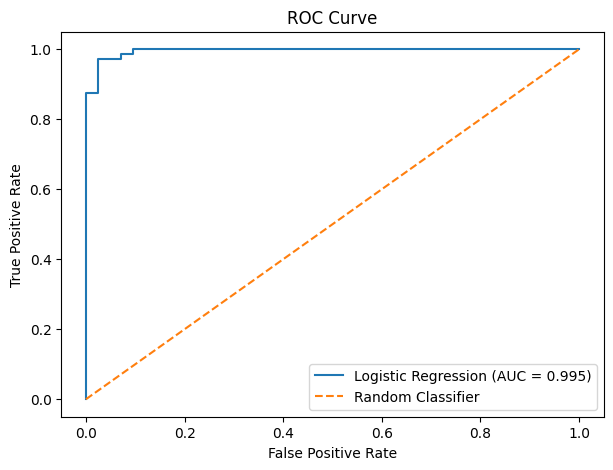

AUC Score: 0.9953703703703703


In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate predicted probabilities for the benign class
y_prob = sigmoid(np.dot(X_test_norm, w_final) + b_final)

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("AUC Score:", auc_score)

## Sample Predictions

The table below compares the actual and predicted classifications for a sample of the test data.

In [40]:
label_names = {
    0: "Malignant",
    1: "Benign"
}

comparison = pd.DataFrame({
    "Actual": [label_names[int(x)] for x in y_test[:10]],
    "Predicted": [label_names[int(x)] for x in y_pred[:10]],
    "Correct": y_test[:10] == y_pred[:10]
})

comparison

,Actual,Predicted,Correct
0,Malignant,Malignant,True
1,Benign,Benign,True
2,Malignant,Malignant,True
3,Benign,Benign,True
4,Malignant,Malignant,True
5,Benign,Benign,True
6,Benign,Benign,True
7,Malignant,Malignant,True
8,Malignant,Malignant,True
9,Malignant,Malignant,True


## Conclusion

This project implemented logistic regression from scratch using NumPy to classify breast tumors as malignant or benign.

The model included:

- Z-score feature normalization
- Sigmoid activation
- Logistic loss computation
- Gradient calculation
- L2 regularization
- Batch gradient descent
- Classification using a probability threshold
- Evaluation using classification metrics and visualizations

The model achieved an accuracy of approximately **97.4%** and an AUC score of **0.995**. It correctly identified **41 out of 42 malignant cases**, achieving a malignant recall of approximately **97.6%**.

These results demonstrate that logistic regression can perform strongly on this binary classification dataset. Future improvements could include hyperparameter tuning, threshold optimization, cross-validation, and comparison with other classification algorithms.